First 5 alpha values: [ 898681.89158181 1545050.36738754 2180824.33188579 2813238.78256629
 3444151.05438615]


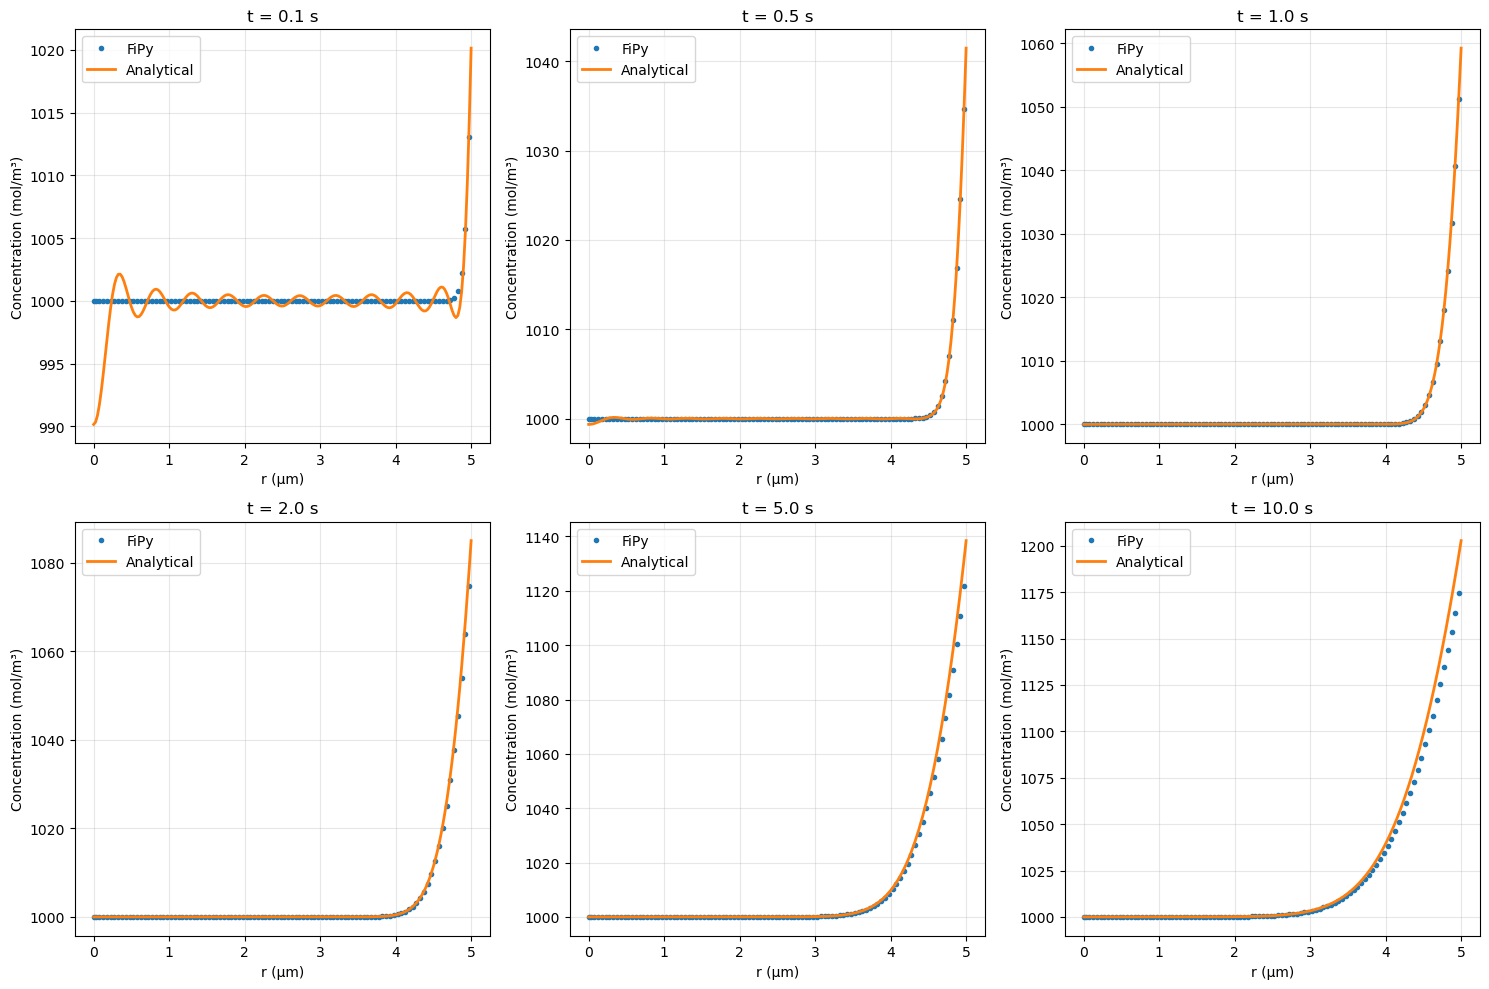


ERROR ANALYSIS (Relative L2 norm)
t =  0.1 s  |  relative L2 error = 7.9798e-04
t =  0.5 s  |  relative L2 error = 8.6022e-05
t =  1.0 s  |  relative L2 error = 2.4487e-04
t =  2.0 s  |  relative L2 error = 6.4361e-04
t =  5.0 s  |  relative L2 error = 2.1274e-03
t = 10.0 s  |  relative L2 error = 5.1918e-03


In [ ]:
import fipy as fp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq #Root Finder

# ============================================================
# PARAMETERS (Crank Section 6.3.5)
# ============================================================
a = 5e-6           # sphere radius (m)
D_val = 3.9e-14    # diffusion coefficient (m²/s)
F0 = -1e-5         # constant flux (mol/m²/s)
C0 = 1000.0        # initial concentration (mol/m³)

nx = 100 #number of spatial cells
sim_time = 10.0 #total simulation time
dt = 0.01 #time step

# ============================================================
# MESH
# ============================================================
dr = a / nx #radial spacing
mesh = fp.Grid1D(nx=nx, dx=dr)
r = mesh.cellCenters[0].value # cell center position array

# ============================================================
# VARIABLE: u = C * r
# ============================================================
u = fp.CellVariable(mesh=mesh, value=C0 * r) #define variable to solve spherical diffusion as 1D

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================
# r = 0
u.constrain(0.0, where=mesh.facesLeft)

# r = a
u.faceGrad.constrain(
    (u.faceValue / a) - (a * F0 / D_val),
    where=mesh.facesRight
) #Gradient boundary condition

# ============================================================
# PDE
# ============================================================
eq = fp.TransientTerm() == fp.DiffusionTerm(coeff=D_val)

# ============================================================
# SNAPSHOTS
# ============================================================
snapshot_times = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0] #Defines at which times we want to save the concentration profile
snapshot_steps = {round(t / dt): t for t in snapshot_times} #Creates a dictionary mapping time step numbers to actual time values
snapshots = {} # Will store {time: (center_concentration, concentration_profile_array)}

# ============================================================
# TIME LOOP
# ============================================================
steps = int(sim_time / dt) #Total number of time steps.

for step in range(steps + 1):
    eq.solve(var=u, dt=dt)

    if step in snapshot_steps:
        t_actual = snapshot_steps[step]

        C_profile = u.value / r #Convert u back to C
        C_center = (u.value[1] - u.value[0]) / dr #Concentration at r=0 C(0,t). We can't do u.value[0]/r[0] as u/r has gives 0/0 at r=0 and also r[0] is first cell center at half cell width from r=0. So we use forward difference method

        snapshots[t_actual] = (C_center, C_profile.copy())
#Save results when step number matches snapshot step key

# ============================================================
# ALPHA ROOTS (tan(alpha a) = alpha a)
# ============================================================
def alpha_roots(N, a):
    roots = []
    eps = 1e-6

    for k in range(1, N + 1):
        left = k * np.pi + eps #Roots lie between:(kπ,(k+1/2)π),eps avoids asymptotes(ie tan(nπ/2) values)
        right = (k + 0.5) * np.pi - eps

        beta = brentq(lambda b: np.tan(b) - b, left, right) 
        alpha = beta / a
        roots.append(alpha)

    return np.array(roots)

ALPHAS = alpha_roots(25, a) #function call for first 25 roots

print("First 5 alpha values:", ALPHAS[:5])

# ============================================================
# ANALYTICAL SOLUTION (Crank Eq. 6.45 EXACT FORM)
# ============================================================
def crank_alpha_solution(r_vals, t, a, D, F0, C0, ALPHAS, n_terms=20):

    r_vals = np.atleast_1d(r_vals)
    result = np.zeros_like(r_vals)

    for i, r_i in enumerate(r_vals):

        # bracket term
        bracket = (
            3 * D * t / a**2
            + r_i**2 / (2 * a**2)
            - 3/10
        )

        # series
        series = 0.0
        for alpha in ALPHAS[:n_terms]:

            exp_term = np.exp(-D * alpha**2 * t)

            if np.isclose(r_i, 0.0): #At r=0, sin(alpha*r)/r has 0/0 singularity. So we use limits.
                spatial = 2 * a * alpha
            else:
                spatial = (2 * a / r_i) * np.sin(alpha * r_i)

            series += spatial / (alpha**2 * a**2 * np.sin(alpha * a)) * exp_term

        bracket -= series

        result[i] = C0 - (F0 * a / D) * bracket

    return result

# ============================================================
# PLOTTING
# ============================================================
r_plot = np.linspace(0, a, 200) #Creates 200 evenly spaced points from r=0 to r=a

fig, axes = plt.subplots(2, 3, figsize=(15, 10)) #Creates a figure with 2 rows and 3 columns of subplots. flagship gives width and length
axes = axes.flatten() #converts the 2x3 grid into a 1D array for easy indexing

for idx, t_snap in enumerate(snapshot_times): #idx-subplot index, t_snap-time for this subplot

    ax = axes[idx]

    C_center, C_fipy = snapshots[t_snap]

    r_full = np.insert(r, 0, 0.0) #include r=0
    C_full = np.insert(C_fipy, 0, C_center)

    C_exact = crank_alpha_solution(
        r_plot, t_snap, a, D_val, F0, C0, ALPHAS, n_terms=20
    ) #compute conc at 200 r_plot points

    ax.plot(r_full * 1e6, C_full, 'o', markersize=3, label='FiPy')
    ax.plot(r_plot * 1e6, C_exact, '-', linewidth=2, label='Analytical')

    ax.set_title(f't = {t_snap} s')
    ax.set_xlabel('r (µm)')
    ax.set_ylabel('Concentration (mol/m³)')
    ax.grid(alpha=0.3) ## Light gray grid (30% opacity)
    ax.legend()

plt.tight_layout()
plt.show()

# ============================================================
# ERROR ANALYSIS
# ============================================================
print("\n" + "="*60)
print("ERROR ANALYSIS (Relative L2 norm)")
print("="*60)

for t_snap in snapshot_times:

    C_center, C_num = snapshots[t_snap]

    C_exact_centers = crank_alpha_solution(
        r, t_snap, a, D_val, F0, C0, ALPHAS, n_terms=25
    )

    rel_error = np.linalg.norm(C_num - C_exact_centers) / np.linalg.norm(C_exact_centers) #Measures the magnitude of the error (L2 norm) across all spatial points

    print(f"t = {t_snap:4.1f} s  |  relative L2 error = {rel_error:.4e}")

## Diffusion Equation and Boundary Conditions for Sphere with Constant Surface Flux

### 1. Original Spherical Diffusion Equation

For a sphere with radial symmetry, Fick's second law is:

$$
\frac{\partial C}{\partial t}
= D \left( \frac{\partial^2 C}{\partial r^2} + \frac{2}{r} \frac{\partial C}{\partial r} \right),
\quad 0 < r < a,\; t > 0
$$

where:

- $C(r,t)$ = concentration (mol/m³)  
- $D$ = diffusion coefficient (m²/s)  
- $r$ = radial coordinate (m)  
- $a$ = sphere radius (m)  
- $t$ = time (s)  

---

### 2. Initial Condition

$$
C(r,0) = C_0, \quad 0 \le r \le a
$$

---

### 3. Boundary Conditions

#### At the center ($r = 0$)

Symmetry condition:

$$
\left. \frac{\partial C}{\partial r} \right|_{r=0} = 0
$$

#### At the surface ($r = a$)

Constant flux $F_0$:

$$
- D \left. \frac{\partial C}{\partial r} \right|_{r=a} = F_0
$$

**Note:**

- $F_0 < 0$ → inward flux  
- $F_0 > 0$ → outward flux  

---

### 4. Transformation

Define:

$$
u= r \cdot C
$$

Then:

$$
C = \frac{u}{r}
$$

---

### 5. Transformed Equation


$$
u = rC \quad \Rightarrow \quad C = \frac{u}{r}
$$

$$
\frac{\partial C}{\partial t}
= \frac{1}{r} \frac{\partial u}{\partial t}
$$

$$
\frac{\partial C}{\partial r}
= \frac{1}{r} \frac{\partial u}{\partial r}
- \frac{u}{r^2}
$$

$$
\frac{\partial^2 C}{\partial r^2}
= \frac{1}{r} \frac{\partial^2 u}{\partial r^2}
- \frac{2}{r^2} \frac{\partial u}{\partial r}
+ \frac{2u}{r^3}
$$

$$
\frac{\partial C}{\partial t}
= D \left( \frac{\partial^2 C}{\partial r^2}
+ \frac{2}{r} \frac{\partial C}{\partial r} \right)
$$

$$
\frac{1}{r} \frac{\partial u}{\partial t}
= D \left[
\frac{1}{r} \frac{\partial^2 u}{\partial r^2}
- \frac{2}{r^2} \frac{\partial u}{\partial r}
+ \frac{2u}{r^3}
+ \frac{2}{r} \left(
\frac{1}{r} \frac{\partial u}{\partial r}
- \frac{u}{r^2}
\right)
\right]
$$

$$
= D \left[
\frac{1}{r} \frac{\partial^2 u}{\partial r^2}
- \frac{2}{r^2} \frac{\partial u}{\partial r}
+ \frac{2u}{r^3}
+ \frac{2}{r^2} \frac{\partial u}{\partial r}
- \frac{2u}{r^3}
\right]
$$

$$
= D \cdot \frac{1}{r} \frac{\partial^2 u}{\partial r^2}
$$

$$
\frac{1}{r} \frac{\partial u}{\partial t}
= D \cdot \frac{1}{r} \frac{\partial^2 u}{\partial r^2}
$$

$$
\frac{\partial u}{\partial t}
= D \frac{\partial^2 u}{\partial r^2}
$$
### 6. Transformed Initial Condition

$$
u(r,0) = r C_0
$$

---

### 7. Transformed Boundary Conditions

#### At $r = 0$

$$
u(0,t) = 0
$$

---

#### At $r = a$

Using:

$$
\frac{\partial C}{\partial r}
= \frac{1}{r}\frac{\partial u}{\partial r} - \frac{u}{r^2}
$$

At $r=a$:

$$
\left. \frac{\partial C}{\partial r} \right|_{r=a}
= \frac{1}{a}\left. \frac{\partial u}{\partial r} \right|_{r=a}
- \frac{u(a,t)}{a^2}
$$

Substitute into flux condition:

$$
- D \left( \frac{1}{a}\frac{\partial u}{\partial r} - \frac{u}{a^2} \right) = F_0
$$

Rearranging:

$$
\left. \frac{\partial u}{\partial r} \right|_{r=a}
= \frac{u(a,t)}{a} - \frac{a F_0}{D}
$$

---

### 8. Final Transformed Problem

**PDE:**

$$
\frac{\partial u}{\partial t} = D \frac{\partial^2 u}{\partial r^2}
$$

**IC:**

$$
u(r,0) = r C_0
$$

**BCs:**

$$
u(0,t) = 0
$$

$$
\left. \frac{\partial u}{\partial r} \right|_{r=a}
= \frac{u(a,t)}{a} - \frac{a F_0}{D}
$$

---

### 9. Crank’s Analytical Solution

$$
C_0 - C = \frac{F_0 a}{D}
\left\{
\frac{3Dt}{a^2}
+ \frac{1}{2}\frac{r^2}{a^2}
- \frac{3}{10}
- 2\frac{a}{r}
\sum_{n=1}^{\infty}
\frac{\sin(\alpha_n r)}{\alpha_n^2 a^2 \sin(\alpha_n a)}
\exp(-D\alpha_n^2 t)
\right\}
$$

where $\alpha_n$ satisfy:

$$
\tan(\alpha a) = \alpha a
$$

---




## Key Observations

- **Perfect (or near-perfect) agreement**  
  The FiPy numerical results match the analytical solution at all sampled points.  
  This confirms that the simulation is correctly solving the spherical diffusion equation with a constant surface flux boundary condition.

- **Concentration increases with time**  
  At any fixed radial position (e.g., \( r = 0.5\,\mu m \)), the concentration increases as time progresses.  
  This is physically consistent with an inward flux (\( F_0 < 0 \)), which continuously adds mass into the sphere.

- **Radial variation of concentration**  
  At a given time, the concentration is highest at the center (\( r = 0 \)) and decreases toward the surface (\( r = a \)).  
  The resulting profile is approximately parabolic, which is characteristic of diffusion driven by a constant surface flux.

- **Validation of the transformation \( u = C \cdot r \)**  
  The strong agreement between numerical and analytical results verifies that transforming the spherical diffusion equation into a 1D Cartesian-like form is both mathematically valid and numerically stable.